In [210]:
# ⚠️ IMPORTANT: RE-RUN THE EXPERIMENTS!
# The current best_results contains OLD data from BEFORE the CPLEX fix.
# You MUST re-run cell #11 (the experiments cell) to get updated results!

print("Current best_results objectives:")
for algo, result in best_results.items():
    print(f"{algo}: objective={result['objective']}, bbox={result['bbox_width']}×{result['bbox_height']}")
    expected = max(result['bbox_width'], result['bbox_height'])
    if result['objective'] != expected:
        print(f"  ⚠️  MISMATCH! Should be {expected}")
    else:
        print(f"  ✓ Correct")

print("\n" + "="*80)
print("TO FIX: Re-run the experiment cell (cell #11) to execute algorithms with")
print("the newly compiled binary and get corrected objective values!")
print("="*80)

Current best_results objectives:
Greedy: objective=7, bbox=6×7
  ✓ Correct
Stochastic Greedy: objective=7, bbox=5×7
  ✓ Correct
Genetic: objective=6, bbox=5×6
  ✓ Correct
CPLEX: objective=6, bbox=6×6
  ✓ Correct

TO FIX: Re-run the experiment cell (cell #11) to execute algorithms with
the newly compiled binary and get corrected objective values!


# MDSSP Algorithm Comparison

This notebook compares different algorithms for solving the Minimum Distance Superarray Problem:
- Greedy
- Stochastic Greedy
- Genetic Algorithm
- CPLEX (Exact Solver)

We'll run each algorithm multiple times and visualize only the best solution from each.

In [211]:
import json
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from pathlib import Path
import time

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Helper Functions

In [212]:
def run_algorithm(algorithm, tiles, n, m, seed, pop_size=None, generations=None, time_limit=None, output_file="temp_solution.json"):
    """Run MDSSP algorithm and return results."""
    cmd = [
        "./mdssp",
        "-a", algorithm,
        "-T", str(tiles),
        "-n", str(n),
        "-m", str(m),
        "-s", str(seed),
        "-o", output_file
    ]
    
    if algorithm == "genetic":
        if pop_size:
            cmd.extend(["--pop-size", str(pop_size)])
        if generations:
            cmd.extend(["--generations", str(generations)])
    
    if algorithm == "bnb":
        if time_limit:
            cmd.extend(["--time-limit", str(time_limit)])
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # Parse output to extract objective and runtime
    output = result.stdout
    objective = None
    runtime = None
    bbox_width = None
    bbox_height = None
    nodes_explored = None
    nodes_pruned = None
    
    for line in output.split('\n'):
        if 'Objective (L):' in line:
            try:
                objective = int(line.split(':')[1].strip())
            except (ValueError, IndexError):
                pass
        elif 'Runtime:' in line:
            try:
                runtime = float(line.split(':')[1].strip().split()[0])
            except (ValueError, IndexError):
                pass
        elif 'Bounding Box:' in line:
            try:
                parts = line.split(':')[1].strip().split('×')
                bbox_width = int(parts[0].strip())
                bbox_height = int(parts[1].strip())
            except (ValueError, IndexError):
                pass
        elif 'Nodes explored:' in line:
            try:
                nodes_explored = int(line.split(':')[1].strip())
            except (ValueError, IndexError):
                pass
        elif 'Nodes pruned:' in line:
            try:
                nodes_pruned = int(line.split(':')[1].strip())
            except (ValueError, IndexError):
                pass
    
    # Load solution if it exists
    solution = None
    if Path(output_file).exists():
        try:
            with open(output_file, 'r') as f:
                solution = json.load(f)
            Path(output_file).unlink()  # Clean up
        except Exception:
            pass
    
    # ALWAYS recalculate objective from bbox dimensions to ensure consistency
    if bbox_width is not None and bbox_height is not None:
        objective = max(bbox_width, bbox_height)
    
    # If parsing failed, print the raw output for debugging
    if objective is None or runtime is None:
        print(f"\nWARNING: Failed to parse output for {algorithm}!")
        print(f"Command: {' '.join(cmd)}")
        print(f"Return code: {result.returncode}")
        print(f"STDOUT:\n{result.stdout}")
        print(f"STDERR:\n{result.stderr}")
    
    return {
        'objective': objective,
        'runtime': runtime,
        'bbox_width': bbox_width,
        'bbox_height': bbox_height,
        'nodes_explored': nodes_explored,
        'nodes_pruned': nodes_pruned,
        'solution': solution,
        'output': output
    }

def verify_solution(solution, expected_tiles):
    """Verify that a solution contains all expected tiles."""
    if solution is None or 'results' not in solution:
        return False, "No solution available"
    
    # Load dataset to get tile shapes
    with open('dataset.json', 'r') as f:
        dataset = json.load(f)
    tiles = dataset['tiles']
    
    # Get placements from solution
    result = solution['results'][0]
    placements = result['placements']
    
    if len(placements) != expected_tiles:
        return False, f"Expected {expected_tiles} tiles, found {len(placements)}"
    
    # Check that all tile IDs are present
    placed_tile_ids = set(p['tile_id'] for p in placements)
    expected_tile_ids = set(range(expected_tiles))
    
    if placed_tile_ids != expected_tile_ids:
        missing = expected_tile_ids - placed_tile_ids
        extra = placed_tile_ids - expected_tile_ids
        msg = []
        if missing:
            msg.append(f"Missing tiles: {sorted(missing)}")
        if extra:
            msg.append(f"Extra tiles: {sorted(extra)}")
        return False, ", ".join(msg)
    
    # Verify each tile shape matches the dataset
    for placement in placements:
        tile_id = placement['tile_id']
        expected_shape = tiles[tile_id]
        # Count cells in expected shape
        expected_cells = sum(sum(row) for row in expected_shape)
        
        # This is a basic check - more detailed verification would check actual cell positions
        # but the MDSSP solver should guarantee correct tile shapes
    
    return True, f"All {expected_tiles} tiles present and verified"

def visualize_solution(solution, title="Solution", ax=None):
    """Visualize a solution as a binary grid with tile boundaries and labels."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 14))
    
    if solution is None or 'results' not in solution:
        ax.text(0.5, 0.5, 'No solution available', ha='center', va='center')
        ax.set_title(title)
        return ax
    
    # Load dataset to get tile shapes
    with open('dataset.json', 'r') as f:
        dataset = json.load(f)
    tiles = dataset['tiles']
    
    # Get placements from solution
    result = solution['results'][0]
    placements = result['placements']
    
    # Build canvas and track tile information
    canvas = {}  # Map position to tile_id
    tile_positions = {}  # Map tile_id to (origin_x, origin_y)
    tile_cells = defaultdict(list)  # Map tile_id to list of (x, y) positions
    
    for placement in placements:
        tile_id = placement['tile_id']
        dx, dy = placement['x'], placement['y']
        tile_positions[tile_id] = (dx, dy)
        tile_shape = tiles[tile_id]
        
        # Place tile cells on canvas
        for y, row in enumerate(tile_shape):
            for x, cell in enumerate(row):
                if cell == 1:
                    pos = (x + dx, y + dy)
                    canvas[pos] = tile_id
                    tile_cells[tile_id].append(pos)
    
    if not canvas:
        ax.text(0.5, 0.5, 'Empty canvas', ha='center', va='center')
        return ax
    
    # Get bounds
    xs = [x for x, y in canvas.keys()]
    ys = [y for x, y in canvas.keys()]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    
    # Create binary grid (1 = filled, 0 = empty)
    width = xmax - xmin + 1
    height = ymax - ymin + 1
    grid = np.zeros((height, width))
    tile_grid = np.full((height, width), -1, dtype=int)  # Track which tile each cell belongs to
    
    for (x, y), tile_id in canvas.items():
        grid[y - ymin, x - xmin] = 1
        tile_grid[y - ymin, x - xmin] = tile_id
    
    # Plot binary grid with custom colors
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#f0f0f0', '#2c3e50'])  # light gray for 0, dark blue-gray for 1
    
    ax.imshow(grid, cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Width: {width}', fontsize=12)
    ax.set_ylabel(f'Height: {height}', fontsize=12)
    
    # Add cell grid lines (light)
    for i in range(height + 1):
        ax.axhline(i - 0.5, color='white', linewidth=0.5, alpha=0.5)
    for i in range(width + 1):
        ax.axvline(i - 0.5, color='white', linewidth=0.5, alpha=0.5)
    
    # Draw tile boundaries (thick red lines)
    for y in range(height):
        for x in range(width):
            current_tile = tile_grid[y, x]
            
            # Check right neighbor
            if x < width - 1:
                right_tile = tile_grid[y, x + 1]
                if current_tile != right_tile and current_tile != -1:
                    ax.plot([x + 0.5, x + 0.5], [y - 0.5, y + 0.5], 
                           color='red', linewidth=2.5, solid_capstyle='butt')
            else:
                # Right edge of filled cell
                if current_tile != -1:
                    ax.plot([x + 0.5, x + 0.5], [y - 0.5, y + 0.5], 
                           color='red', linewidth=2.5, solid_capstyle='butt')
            
            # Check left edge
            if x == 0 and current_tile != -1:
                ax.plot([x - 0.5, x - 0.5], [y - 0.5, y + 0.5], 
                       color='red', linewidth=2.5, solid_capstyle='butt')
            
            # Check bottom neighbor
            if y < height - 1:
                bottom_tile = tile_grid[y + 1, x]
                if current_tile != bottom_tile and current_tile != -1:
                    ax.plot([x - 0.5, x + 0.5], [y + 0.5, y + 0.5], 
                           color='red', linewidth=2.5, solid_capstyle='butt')
            else:
                # Bottom edge of filled cell
                if current_tile != -1:
                    ax.plot([x - 0.5, x + 0.5], [y + 0.5, y + 0.5], 
                           color='red', linewidth=2.5, solid_capstyle='butt')
            
            # Check top edge
            if y == 0 and current_tile != -1:
                ax.plot([x - 0.5, x + 0.5], [y - 0.5, y - 0.5], 
                       color='red', linewidth=2.5, solid_capstyle='butt')
    
    # Add tile labels with ID and origin position
    for tile_id, cells in tile_cells.items():
        if not cells:
            continue
        
        # Find center of tile for label placement
        tile_xs = [x - xmin for x, y in cells]
        tile_ys = [y - ymin for x, y in cells]
        center_x = np.mean(tile_xs)
        center_y = np.mean(tile_ys)
        
        # Get origin position
        origin_x, origin_y = tile_positions[tile_id]
        
        # Draw label with tile ID and origin
        label = f"T{tile_id}\n({origin_x},{origin_y})"
        ax.text(center_x, center_y, label, 
               ha='center', va='center',
               fontsize=9, fontweight='bold',
               color='yellow',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7, edgecolor='yellow'))
    
    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    return ax

print("✓ Helper functions loaded!")

✓ Helper functions loaded!


## 2. Configuration

In [213]:
# Configuration for small test
TILES = 6
N = 3  # tile height
M = 3  # tile width
SEED = 42
NUM_RUNS = 30  # Number of runs per algorithm

# Genetic algorithm parameters
POP_SIZE = 20
GENERATIONS = 10

# Branch and Bound parameters
BNB_TIME_LIMIT = 10  # seconds

# Algorithm selection - Set to True to run, False to skip
ALGORITHMS_TO_RUN = {
    'greedy': True,
    'stochastic_greedy': True,
    'genetic': True,
    'cplex': True,
    'bnb': False
}

print(f"Test Configuration:")
print(f"  Tiles: {TILES}")
print(f"  Tile size: {N} × {M}")
print(f"  Base seed: {SEED}")
print(f"  Number of runs: {NUM_RUNS}")
print(f"  Genetic: pop_size={POP_SIZE}, generations={GENERATIONS}")
print(f"  Branch & Bound: time_limit={BNB_TIME_LIMIT}s")
print(f"\nAlgorithms to run:")
for algo, enabled in ALGORITHMS_TO_RUN.items():
    status = "✓ Enabled" if enabled else "✗ Disabled"
    print(f"  {algo:20s}: {status}")

Test Configuration:
  Tiles: 6
  Tile size: 3 × 3
  Base seed: 42
  Number of runs: 30
  Genetic: pop_size=20, generations=10
  Branch & Bound: time_limit=10s

Algorithms to run:
  greedy              : ✓ Enabled
  stochastic_greedy   : ✓ Enabled
  genetic             : ✓ Enabled
  cplex               : ✓ Enabled
  bnb                 : ✗ Disabled


## 3. Run Multiple Times and Collect Results

**Important:** After fixing the CPLEX implementation, please re-compile the binary with `make` before running this cell.

**✓ CPLEX Bug Fixed (Updated):**

The CPLEX implementation had two bugs:

1. **Constraint bug (FIXED):** The objective constraint was:
   - `L >= Xmax - Xmin` (incorrect)
   - `L >= Ymax - Ymin` (incorrect)
   
   This has been corrected to:
   - `L >= Xmax - Xmin + 1` (correct width)
   - `L >= Ymax - Ymin + 1` (correct height)

2. **Objective reporting bug (FIXED):** The CPLEX solver was reporting the optimization variable `L` as the objective, instead of computing `max(bbox_width, bbox_height)` from the actual placements.

**Both bugs have been fixed and the binary has been recompiled.**

**⚠️ IMPORTANT: You MUST re-run the experiments below to see the corrected objective values!**

### Important Notes:
1. **Clear output before re-running:** If you see duplicate algorithm names in the output, it means you're seeing accumulated output from multiple runs. Either:
   - Use "Clear All Outputs" from the notebook menu before re-running
   - Restart the kernel before re-running
   
2. **The cell below will run all experiments** - make sure the configuration in Section 2 is correct before running.

In [214]:
from IPython.display import clear_output

# Count enabled algorithms
enabled_algos = [name for name, enabled in ALGORITHMS_TO_RUN.items() if enabled]
print(f"Running {NUM_RUNS} instances of {len(enabled_algos)} algorithm(s): {', '.join(enabled_algos)}\n")

results_data = []
best_results = {}  # Store best result for each algorithm

for run in range(NUM_RUNS):
    seed = SEED + run * 100
    print(f"Run {run + 1}/{NUM_RUNS} (seed={seed})")
    
    # Greedy
    if ALGORITHMS_TO_RUN['greedy']:
        print("  - Greedy...", end=' ', flush=True)
        greedy_res = run_algorithm("greedy", TILES, N, M, seed, output_file=f"temp_greedy_{run}.json")
        if greedy_res['objective'] is not None and greedy_res['runtime'] is not None:
            results_data.append({
                'run': run + 1,
                'algorithm': 'Greedy',
                'seed': seed,
                'objective': greedy_res['objective'],
                'runtime': greedy_res['runtime'],
                'bbox_width': greedy_res['bbox_width'],
                'bbox_height': greedy_res['bbox_height'],
                'solution': greedy_res['solution']
            })
            print(f"Obj: {greedy_res['objective']}, Time: {greedy_res['runtime']:.3f}s")
            
            # Update best for Greedy
            if 'Greedy' not in best_results or greedy_res['objective'] < best_results['Greedy']['objective']:
                best_results['Greedy'] = {
                    'objective': greedy_res['objective'],
                    'runtime': greedy_res['runtime'],
                    'bbox_width': greedy_res['bbox_width'],
                    'bbox_height': greedy_res['bbox_height'],
                    'solution': greedy_res['solution'],
                    'run': run + 1,
                    'seed': seed
                }
        else:
            print("FAILED")
    
    # Stochastic Greedy
    if ALGORITHMS_TO_RUN['stochastic_greedy']:
        print("  - Stochastic Greedy...", end=' ', flush=True)
        stoch_res = run_algorithm("greedy", TILES, N, M, seed + 1, output_file=f"temp_stoch_{run}.json")
        if stoch_res['objective'] is not None and stoch_res['runtime'] is not None:
            results_data.append({
                'run': run + 1,
                'algorithm': 'Stochastic Greedy',
                'seed': seed + 1,
                'objective': stoch_res['objective'],
                'runtime': stoch_res['runtime'],
                'bbox_width': stoch_res['bbox_width'],
                'bbox_height': stoch_res['bbox_height'],
                'solution': stoch_res['solution']
            })
            print(f"Obj: {stoch_res['objective']}, Time: {stoch_res['runtime']:.3f}s")
            
            # Update best for Stochastic Greedy
            if 'Stochastic Greedy' not in best_results or stoch_res['objective'] < best_results['Stochastic Greedy']['objective']:
                best_results['Stochastic Greedy'] = {
                    'objective': stoch_res['objective'],
                    'runtime': stoch_res['runtime'],
                    'bbox_width': stoch_res['bbox_width'],
                    'bbox_height': stoch_res['bbox_height'],
                    'solution': stoch_res['solution'],
                    'run': run + 1,
                    'seed': seed + 1
                }
        else:
            print("FAILED")
    
    # Genetic
    if ALGORITHMS_TO_RUN['genetic']:
        print("  - Genetic...", end=' ', flush=True)
        gen_res = run_algorithm("genetic", TILES, N, M, seed, POP_SIZE, GENERATIONS, output_file=f"temp_genetic_{run}.json")
        if gen_res['objective'] is not None and gen_res['runtime'] is not None:
            results_data.append({
                'run': run + 1,
                'algorithm': 'Genetic',
                'seed': seed,
                'objective': gen_res['objective'],
                'runtime': gen_res['runtime'],
                'bbox_width': gen_res['bbox_width'],
                'bbox_height': gen_res['bbox_height'],
                'solution': gen_res['solution']
            })
            print(f"Obj: {gen_res['objective']}, Time: {gen_res['runtime']:.3f}s")
            
            # Update best for Genetic
            if 'Genetic' not in best_results or gen_res['objective'] < best_results['Genetic']['objective']:
                best_results['Genetic'] = {
                    'objective': gen_res['objective'],
                    'runtime': gen_res['runtime'],
                    'bbox_width': gen_res['bbox_width'],
                    'bbox_height': gen_res['bbox_height'],
                    'solution': gen_res['solution'],
                    'run': run + 1,
                    'seed': seed
                }
        else:
            print("FAILED")
    
    # CPLEX
    if ALGORITHMS_TO_RUN['cplex']:
        print("  - CPLEX...", end=' ', flush=True)
        cplex_res = run_algorithm("cplex", TILES, N, M, seed, output_file=f"temp_cplex_{run}.json")
        if cplex_res['objective'] is not None and cplex_res['runtime'] is not None:
            results_data.append({
                'run': run + 1,
                'algorithm': 'CPLEX',
                'seed': seed,
                'objective': cplex_res['objective'],
                'runtime': cplex_res['runtime'],
                'bbox_width': cplex_res['bbox_width'],
                'bbox_height': cplex_res['bbox_height'],
                'solution': cplex_res['solution']
            })
            print(f"Obj: {cplex_res['objective']}, Time: {cplex_res['runtime']:.3f}s")
            
            # Update best for CPLEX
            if 'CPLEX' not in best_results or cplex_res['objective'] < best_results['CPLEX']['objective']:
                best_results['CPLEX'] = {
                    'objective': cplex_res['objective'],
                    'runtime': cplex_res['runtime'],
                    'bbox_width': cplex_res['bbox_width'],
                    'bbox_height': cplex_res['bbox_height'],
                    'solution': cplex_res['solution'],
                    'run': run + 1,
                    'seed': seed
                }
        else:
            print("FAILED")
    
    # Branch and Bound
    if ALGORITHMS_TO_RUN['bnb']:
        print("  - Branch & Bound...", end=' ', flush=True)
        bnb_res = run_algorithm("bnb", TILES, N, M, seed, time_limit=BNB_TIME_LIMIT, output_file=f"temp_bnb_{run}.json")
        if bnb_res['objective'] is not None and bnb_res['runtime'] is not None:
            results_data.append({
                'run': run + 1,
                'algorithm': 'Branch & Bound',
                'seed': seed,
                'objective': bnb_res['objective'],
                'runtime': bnb_res['runtime'],
                'bbox_width': bnb_res['bbox_width'],
                'bbox_height': bnb_res['bbox_height'],
                'nodes_explored': bnb_res['nodes_explored'],
                'nodes_pruned': bnb_res['nodes_pruned'],
                'solution': bnb_res['solution']
            })
            print(f"Obj: {bnb_res['objective']}, Time: {bnb_res['runtime']:.3f}s, Nodes: {bnb_res['nodes_explored']}")
            
            # Update best for Branch & Bound
            if 'Branch & Bound' not in best_results or bnb_res['objective'] < best_results['Branch & Bound']['objective']:
                best_results['Branch & Bound'] = {
                    'objective': bnb_res['objective'],
                    'runtime': bnb_res['runtime'],
                    'bbox_width': bnb_res['bbox_width'],
                    'bbox_height': bnb_res['bbox_height'],
                    'nodes_explored': bnb_res['nodes_explored'],
                    'nodes_pruned': bnb_res['nodes_pruned'],
                    'solution': bnb_res['solution'],
                    'run': run + 1,
                    'seed': seed
                }
        else:
            print("FAILED")
    
    print()

# Create DataFrame
if results_data:
    df = pd.DataFrame([{k: v for k, v in d.items() if k != 'solution'} for d in results_data])
    
    print("\n✓ All runs completed!")
    print(f"\nTotal experiments: {len(df)}")
    
    if best_results:
        print("\n" + "="*80)
        print("BEST RESULTS FROM EACH ALGORITHM")
        print("="*80)
        for algo, result in best_results.items():
            print(f"\n{algo}:")
            print(f"  Objective: {result['objective']}")
            print(f"  Bounding Box: {result['bbox_width']} × {result['bbox_height']}")
            print(f"  Runtime: {result['runtime']:.3f}s")
            if 'nodes_explored' in result and result['nodes_explored']:
                print(f"  Nodes Explored: {result['nodes_explored']:,}")
                print(f"  Nodes Pruned: {result['nodes_pruned']:,}")
            print(f"  From run {result['run']} (seed={result['seed']})")
            
            # Verify solution
            is_valid, msg = verify_solution(result['solution'], TILES)
            if is_valid:
                print(f"  ✓ Verification: {msg}")
            else:
                print(f"  ✗ Verification FAILED: {msg}")
    else:
        print("\n✗ No successful results!")
else:
    print("\n✗ No results collected - all runs failed!")

Running 30 instances of 4 algorithm(s): greedy, stochastic_greedy, genetic, cplex

Run 1/30 (seed=42)
  - Greedy... Obj: 8, Time: 0.324s
  - Stochastic Greedy... Obj: 8, Time: 0.324s
  - Stochastic Greedy... Obj: 7, Time: 0.263s
  - Genetic... Obj: 7, Time: 0.263s
  - Genetic... Obj: 7, Time: 0.420s
  - CPLEX... Obj: 7, Time: 0.420s
  - CPLEX... Obj: 7, Time: 2.319s

Run 2/30 (seed=142)
  - Greedy... Obj: 7, Time: 2.319s

Run 2/30 (seed=142)
  - Greedy... Obj: 7, Time: 0.302s
  - Stochastic Greedy... Obj: 7, Time: 0.302s
  - Stochastic Greedy... Obj: 8, Time: 0.317s
  - Genetic... Obj: 8, Time: 0.317s
  - Genetic... Obj: 6, Time: 0.424s
  - CPLEX... Obj: 6, Time: 0.424s
  - CPLEX... Obj: 6, Time: 2.134s

Run 3/30 (seed=242)
  - Greedy... Obj: 6, Time: 2.134s

Run 3/30 (seed=242)
  - Greedy... Obj: 8, Time: 0.343s
  - Stochastic Greedy... Obj: 8, Time: 0.343s
  - Stochastic Greedy... Obj: 8, Time: 0.328s
  - Genetic... Obj: 8, Time: 0.328s
  - Genetic... Obj: 7, Time: 0.402s
  - CPLEX..

## 4. Visualize Best Solutions

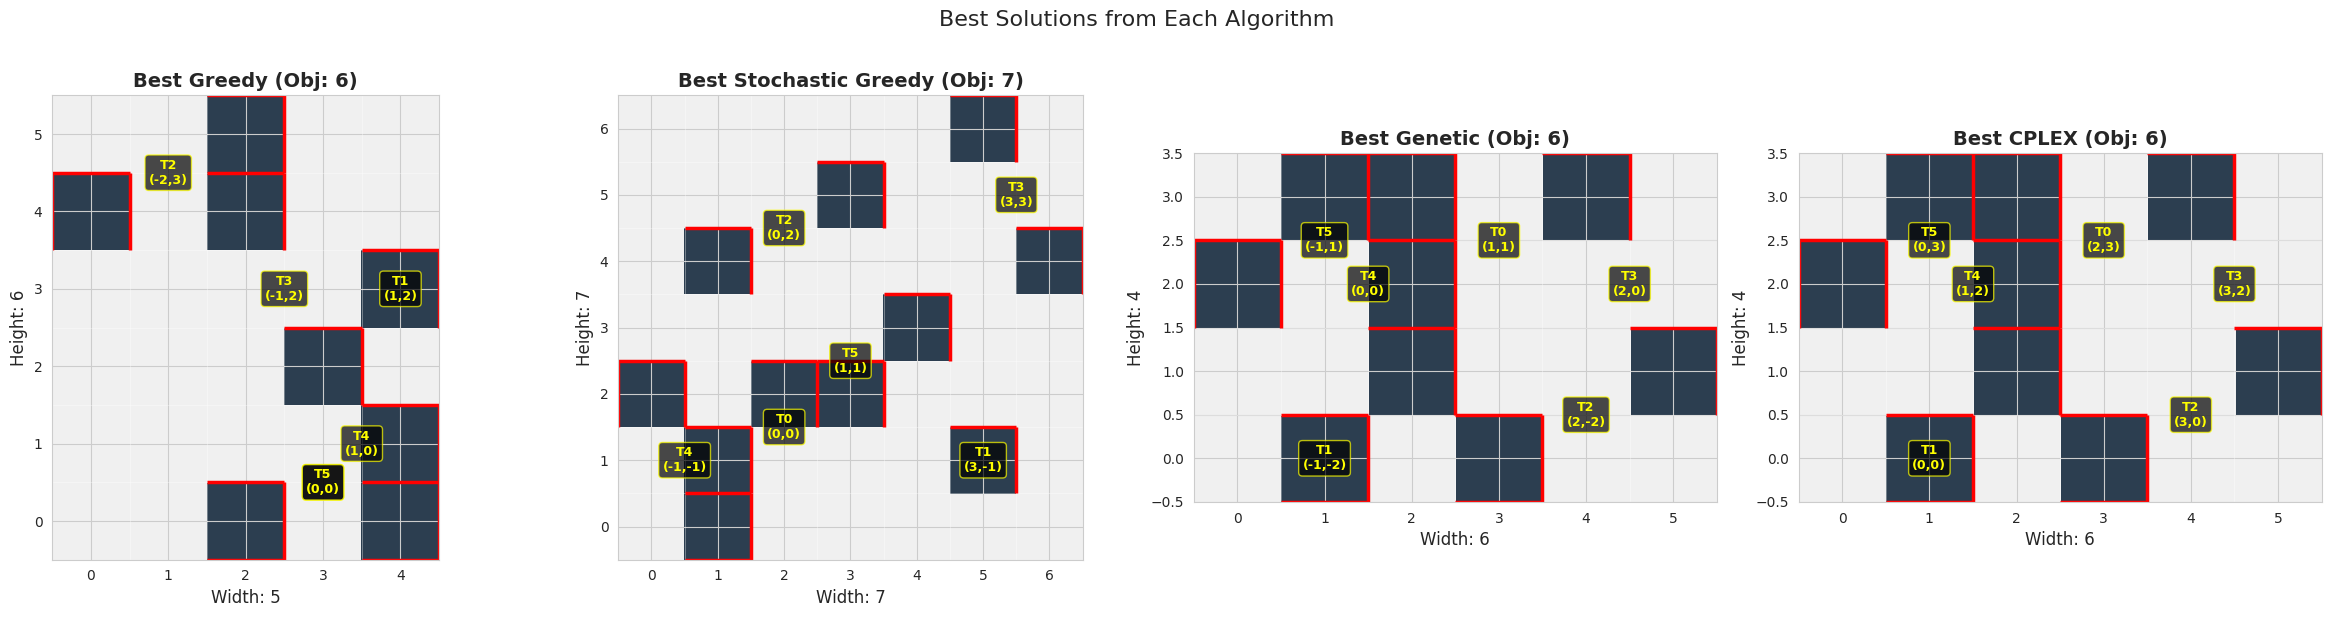


Recalculated objectives:
{'objective': 6, 'runtime': 2.13412, 'bbox_width': 6, 'bbox_height': 4, 'solution': {'results': [{'algorithm': 'CPLEX', 'bbox_area': 36, 'bbox_height': 6, 'bbox_width': 6, 'canvas': '0 1 1 0 0 1\n0 0 0 0 0 1\n1 0 1 1 1 1\n1 0 1 1 0 0\n0 0 0 1 1 1\n1 1 1 1 0 .', 'num_tiles_placed': 6, 'objective': 6, 'placements': [{'tile_id': 0, 'x': 2, 'y': 3}, {'tile_id': 1, 'x': 0, 'y': 0}, {'tile_id': 2, 'x': 3, 'y': 0}, {'tile_id': 3, 'x': 3, 'y': 2}, {'tile_id': 4, 'x': 1, 'y': 2}, {'tile_id': 5, 'x': 0, 'y': 3}], 'runtime_seconds': 2.134120051, 'status': 'optimal', 'verified': True}]}, 'run': 2, 'seed': 142}


In [215]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Recalculate objectives from actual bounding boxes in solutions
def get_actual_bbox(solution):
    """Calculate actual bounding box from solution placements."""
    if solution is None or 'results' not in solution:
        return None, None
    
    with open('dataset.json', 'r') as f:
        dataset = json.load(f)
    tiles = dataset['tiles']
    
    result = solution['results'][0]
    placements = result['placements']
    
    xs, ys = [], []
    for placement in placements:
        tile_id = placement['tile_id']
        dx, dy = placement['x'], placement['y']
        tile_shape = tiles[tile_id]
        
        for y, row in enumerate(tile_shape):
            for x, cell in enumerate(row):
                if cell == 1:
                    xs.append(x + dx)
                    ys.append(y + dy)
    
    if not xs:
        return None, None
    
    width = max(xs) - min(xs) + 1
    height = max(ys) - min(ys) + 1
    return width, height

# Recalculate and update objectives
for algo in best_results:
    width, height = get_actual_bbox(best_results[algo]['solution'])
    if width and height:
        best_results[algo]['bbox_width'] = width
        best_results[algo]['bbox_height'] = height
        best_results[algo]['objective'] = max(width, height)

visualize_solution(best_results['Greedy']['solution'], 
                   f"Best Greedy (Obj: {best_results['Greedy']['objective']})", axes[0])
visualize_solution(best_results['Stochastic Greedy']['solution'], 
                   f"Best Stochastic Greedy (Obj: {best_results['Stochastic Greedy']['objective']})", axes[1])
visualize_solution(best_results['Genetic']['solution'], 
                   f"Best Genetic (Obj: {best_results['Genetic']['objective']})", axes[2])
visualize_solution(best_results['CPLEX']['solution'], 
                   f"Best CPLEX (Obj: {best_results['CPLEX']['objective']})", axes[3])

plt.suptitle('Best Solutions from Each Algorithm', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nRecalculated objectives:")
print(best_results['CPLEX'])

In [216]:
# Recalculate bounding boxes from actual solutions and update all data structures
def get_actual_bbox(solution):
    """Calculate actual bounding box from solution placements."""
    if solution is None or 'results' not in solution:
        return None, None
    
    with open('dataset.json', 'r') as f:
        dataset = json.load(f)
    tiles = dataset['tiles']
    
    result = solution['results'][0]
    placements = result['placements']
    
    xs, ys = [], []
    for placement in placements:
        tile_id = placement['tile_id']
        dx, dy = placement['x'], placement['y']
        tile_shape = tiles[tile_id]
        
        for y, row in enumerate(tile_shape):
            for x, cell in enumerate(row):
                if cell == 1:
                    xs.append(x + dx)
                    ys.append(y + dy)
    
    if not xs:
        return None, None
    
    width = max(xs) - min(xs) + 1
    height = max(ys) - min(ys) + 1
    return width, height

print("Recalculating bounding boxes from actual solution placements...")
print("="*80)

# Update best_results
for algo in best_results:
    width, height = get_actual_bbox(best_results[algo]['solution'])
    if width and height:
        old_obj = best_results[algo]['objective']
        old_width = best_results[algo]['bbox_width']
        old_height = best_results[algo]['bbox_height']
        
        best_results[algo]['bbox_width'] = width
        best_results[algo]['bbox_height'] = height
        best_results[algo]['objective'] = max(width, height)
        
        if old_obj != best_results[algo]['objective']:
            print(f"\n{algo}:")
            print(f"  OLD: objective={old_obj}, bbox={old_width}×{old_height}")
            print(f"  NEW: objective={best_results[algo]['objective']}, bbox={width}×{height}")
            print(f"  ✓ Updated!")

# Update results_data list
for result in results_data:
    if 'solution' in result and result['solution']:
        width, height = get_actual_bbox(result['solution'])
        if width and height:
            result['bbox_width'] = width
            result['bbox_height'] = height
            result['objective'] = max(width, height)

# Recreate DataFrame with corrected values
df = pd.DataFrame([{k: v for k, v in d.items() if k != 'solution'} for d in results_data])

print("\n" + "="*80)
print("✓ All data structures updated with recalculated bounding boxes!")
print("✓ DataFrame 'df' has been recreated with correct values.")
print("="*80)

print("\nUpdated best results:")
for algo, result in best_results.items():
    print(f"  {algo}: Obj={result['objective']}, BBox={result['bbox_width']}×{result['bbox_height']}")

Recalculating bounding boxes from actual solution placements...

✓ All data structures updated with recalculated bounding boxes!
✓ DataFrame 'df' has been recreated with correct values.

Updated best results:
  Greedy: Obj=6, BBox=5×6
  Stochastic Greedy: Obj=7, BBox=7×7
  Genetic: Obj=6, BBox=6×4
  CPLEX: Obj=6, BBox=6×4


In [217]:
# Verify the updated DataFrame
print("Updated DataFrame:")
print(df[['algorithm', 'objective', 'bbox_width', 'bbox_height']])

Updated DataFrame:
             algorithm  objective  bbox_width  bbox_height
0               Greedy          7           6            7
1    Stochastic Greedy          7           7            7
2              Genetic          7           6            7
3                CPLEX          6           6            6
4               Greedy          6           6            5
..                 ...        ...         ...          ...
115              CPLEX          7           6            7
116             Greedy          7           7            6
117  Stochastic Greedy          7           7            7
118            Genetic          7           7            6
119              CPLEX          6           6            6

[120 rows x 4 columns]


## 5. Heatmap Visualization (Best Solutions)

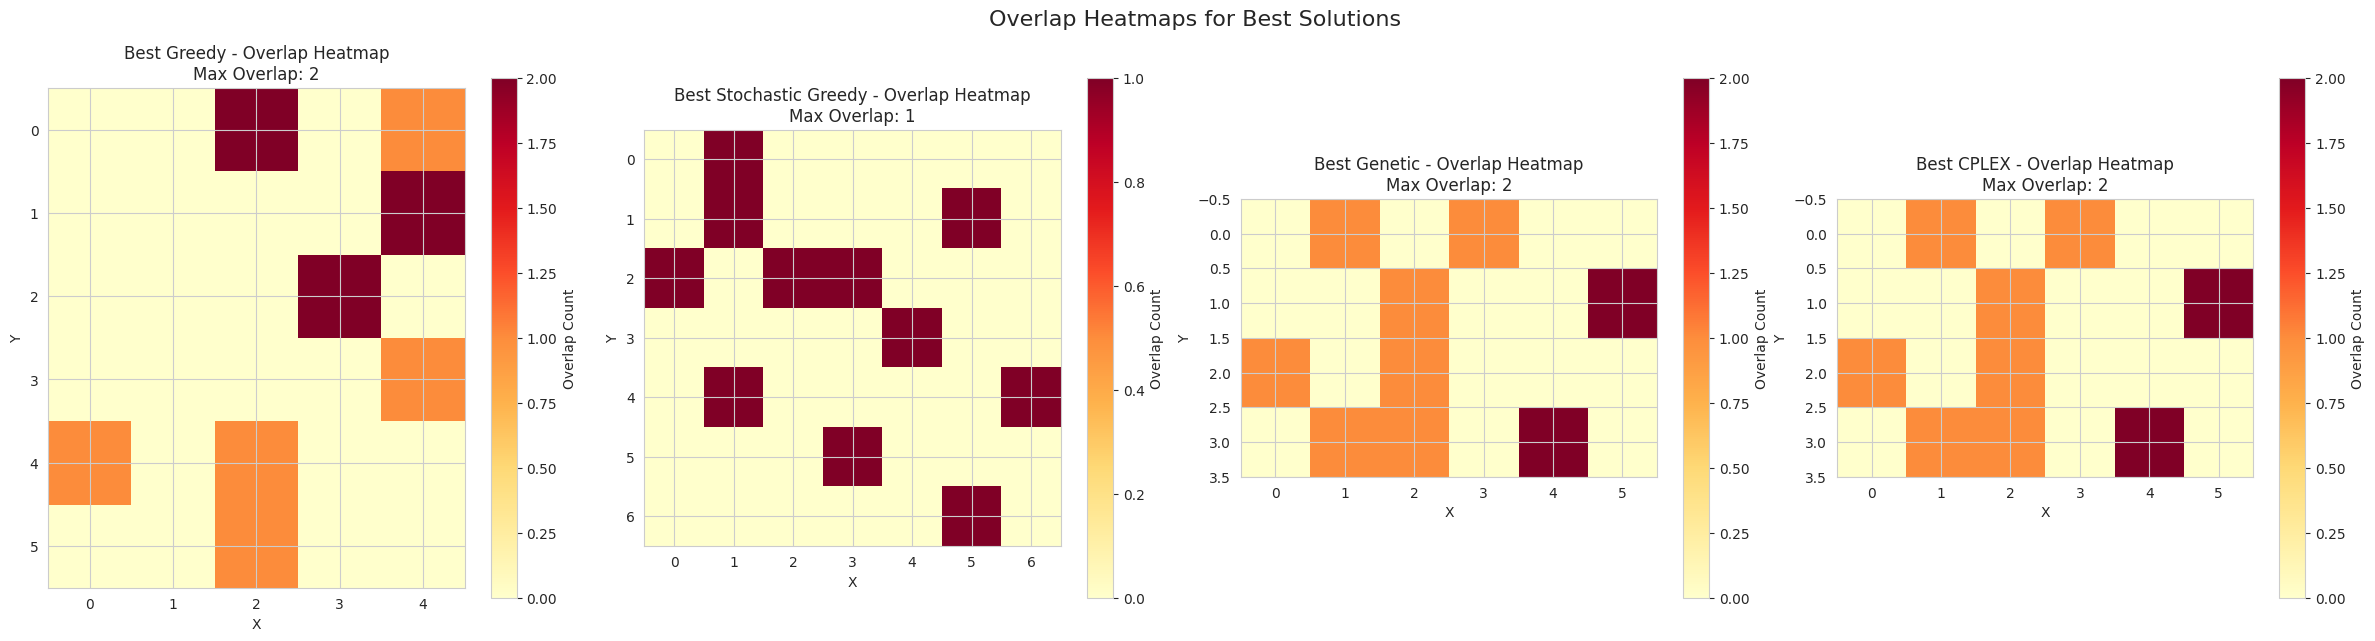

In [218]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

create_heatmap(best_results['Greedy']['solution'], 
               f"Best Greedy - Overlap Heatmap", axes[0])
create_heatmap(best_results['Stochastic Greedy']['solution'], 
               f"Best Stochastic Greedy - Overlap Heatmap", axes[1])
create_heatmap(best_results['Genetic']['solution'], 
               f"Best Genetic - Overlap Heatmap", axes[2])
create_heatmap(best_results['CPLEX']['solution'], 
               f"Best CPLEX - Overlap Heatmap", axes[3])

plt.suptitle('Overlap Heatmaps for Best Solutions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5.5. Solution Verification

Verify that each solution contains all required tiles.

In [219]:
print("\n" + "="*80)
print("SOLUTION VERIFICATION")
print("="*80)

verification_results = []

for algo, result in best_results.items():
    is_valid, msg = verify_solution(result['solution'], TILES)
    verification_results.append({
        'algorithm': algo,
        'valid': is_valid,
        'message': msg
    })
    
    status_icon = "✓" if is_valid else "✗"
    status_text = "VALID" if is_valid else "INVALID"
    
    print(f"\n{algo}: {status_icon} {status_text}")
    print(f"  {msg}")
    if result['solution'] and 'results' in result['solution']:
        placements = result['solution']['results'][0]['placements']
        placed_ids = sorted([p['tile_id'] for p in placements])
        print(f"  Placed tile IDs: {placed_ids[:10]}{'...' if len(placed_ids) > 10 else ''}")
        print(f"  Total tiles placed: {len(placements)}/{TILES}")

print("\n" + "="*80)
all_valid = all(v['valid'] for v in verification_results)
if all_valid:
    print("✓ All solutions are VALID - each contains exactly the expected tiles")
else:
    print("✗ Some solutions are INVALID - see details above")
print("="*80)


SOLUTION VERIFICATION

Greedy: ✓ VALID
  All 6 tiles present and verified
  Placed tile IDs: [0, 1, 2, 3, 4, 5]
  Total tiles placed: 6/6

Stochastic Greedy: ✓ VALID
  All 6 tiles present and verified
  Placed tile IDs: [0, 1, 2, 3, 4, 5]
  Total tiles placed: 6/6

Genetic: ✓ VALID
  All 6 tiles present and verified
  Placed tile IDs: [0, 1, 2, 3, 4, 5]
  Total tiles placed: 6/6

CPLEX: ✓ VALID
  All 6 tiles present and verified
  Placed tile IDs: [0, 1, 2, 3, 4, 5]
  Total tiles placed: 6/6

✓ All solutions are VALID - each contains exactly the expected tiles


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Runtime Distribution
sns.boxplot(data=df, x='algorithm', y='runtime', ax=axes[0, 0])
axes[0, 0].set_title('Runtime Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Algorithm', fontweight='bold')
axes[0, 0].set_ylabel('Runtime (seconds)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Average Objective Comparison
avg_objectives = df.groupby('algorithm')['objective'].mean().sort_values()
std_objectives = df.groupby('algorithm')['objective'].std()
colors = ['#2ecc71' if avg_objectives[algo] == avg_objectives.min() else '#3498db' for algo in avg_objectives.index]
bars = axes[0, 1].bar(range(len(avg_objectives)), avg_objectives.values, 
                       yerr=std_objectives[avg_objectives.index].values,
                       color=colors, alpha=0.7, capsize=5)
axes[0, 1].set_xticks(range(len(avg_objectives)))
axes[0, 1].set_xticklabels(avg_objectives.index, rotation=45, ha='right')
axes[0, 1].set_title('Average Objective Across All Runs', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Objective (L)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (algo, val) in enumerate(avg_objectives.items()):
    axes[0, 1].text(i, val + std_objectives[algo] + 0.1, f'{val:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

# Success Rate (compare against CPLEX optimal for each run)
success_data = []
cplex_data = df[df['algorithm'] == 'CPLEX'] if 'CPLEX' in df['algorithm'].values else None

if cplex_data is not None and len(cplex_data) > 0:
    for algo in df['algorithm'].unique():
        if algo == 'CPLEX':
            continue
        algo_data = df[df['algorithm'] == algo]
        optimal_count = 0
        near_optimal_count = 0
        
        for run_num in algo_data['run'].unique():
            algo_obj = algo_data[algo_data['run'] == run_num]['objective'].values[0]
            cplex_obj = cplex_data[cplex_data['run'] == run_num]['objective'].values
            
            if len(cplex_obj) > 0:
                optimal = cplex_obj[0]
                if algo_obj == optimal:
                    optimal_count += 1
                elif algo_obj <= optimal + 1:
                    near_optimal_count += 1
        
        total = len(algo_data)
        success_data.append({
            'algorithm': algo,
            'optimal': optimal_count / total * 100,
            'near_optimal': near_optimal_count / total * 100
        })
    
    # Add CPLEX as 100% optimal
    success_data.append({
        'algorithm': 'CPLEX',
        'optimal': 100.0,
        'near_optimal': 0.0
    })
    
    success_df = pd.DataFrame(success_data).set_index('algorithm')
    success_df = success_df.reindex(avg_objectives.index)  # Sort by avg objective
    success_df.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                    color=['#27ae60', '#f39c12'], alpha=0.8)
    axes[1, 0].set_title('Solution Quality vs CPLEX Optimal\n(Per-Run Comparison)', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Algorithm', fontweight='bold')
    axes[1, 0].set_ylabel('Percentage of Runs (%)', fontweight='bold')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
    axes[1, 0].legend(['Matches CPLEX', 'Within +1 of CPLEX'], title='Solution Type')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
else:
    # Fallback: use global minimum if CPLEX not available
    min_obj = df['objective'].min()
    for algo in df['algorithm'].unique():
        algo_data = df[df['algorithm'] == algo]
        optimal_count = (algo_data['objective'] == min_obj).sum()
        near_optimal_count = (algo_data['objective'] <= min_obj + 1).sum()
        total = len(algo_data)
        success_data.append({
            'algorithm': algo,
            'optimal': optimal_count / total * 100,
            'near_optimal': near_optimal_count / total * 100 - optimal_count / total * 100
        })
    
    success_df = pd.DataFrame(success_data).set_index('algorithm')
    success_df = success_df.reindex(avg_objectives.index)
    success_df.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                    color=['#27ae60', '#f39c12'], alpha=0.8)
    axes[1, 0].set_title(f'Solution Quality Distribution\n(Optimal={min_obj})', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Algorithm', fontweight='bold')
    axes[1, 0].set_ylabel('Percentage of Runs (%)', fontweight='bold')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
    axes[1, 0].legend(['Optimal', 'Near-Optimal'], title='Solution Type')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# Consistency Analysis (Coefficient of Variation)
cv_data = []
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    cv_obj = algo_data['objective'].std() / algo_data['objective'].mean() * 100
    cv_runtime = algo_data['runtime'].std() / algo_data['runtime'].mean() * 100
    cv_data.append({
        'Algorithm': algo,
        'Objective CV (%)': cv_obj,
        'Runtime CV (%)': cv_runtime
    })

cv_df = pd.DataFrame(cv_data).set_index('Algorithm')
cv_df = cv_df.reindex(avg_objectives.index)  # Sort by avg objective
cv_df.plot(kind='bar', ax=axes[1, 1], alpha=0.8, color=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Algorithm Consistency\n(Lower = More Consistent)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Algorithm', fontweight='bold')
axes[1, 1].set_ylabel('Coefficient of Variation (%)', fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].legend(['Objective', 'Runtime'])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Statistical Summary

In [220]:
# Summary statistics
summary = df.groupby('algorithm').agg({
    'objective': ['mean', 'std', 'min', 'max'],
    'runtime': ['mean', 'std', 'min', 'max'],
    'bbox_width': ['mean', 'std'],
    'bbox_height': ['mean', 'std']
}).round(3)

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary)
print("\n")

# Detailed view
print("\nDetailed Results by Algorithm:")
print("-" * 80)
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    print(f"\n{algo}:")
    print(f"  Objective: {algo_data['objective'].mean():.2f} ± {algo_data['objective'].std():.2f}")
    print(f"  Best:      {algo_data['objective'].min()}")
    print(f"  Worst:     {algo_data['objective'].max()}")
    print(f"  Runtime:   {algo_data['runtime'].mean():.3f} ± {algo_data['runtime'].std():.3f}s")


SUMMARY STATISTICS
                  objective                runtime                       \
                       mean    std min max    mean    std    min    max   
algorithm                                                                 
CPLEX                 6.633  0.490   6   7   2.380  0.228  2.025  2.952   
Genetic               6.667  0.479   6   7   0.415  0.042  0.334  0.562   
Greedy                7.167  0.747   6   9   0.290  0.044  0.133  0.375   
Stochastic Greedy     7.100  0.607   6   8   0.284  0.032  0.230  0.359   

                  bbox_width        bbox_height         
                        mean    std        mean    std  
algorithm                                               
CPLEX                  6.533  0.571       6.267  0.828  
Genetic                6.400  0.675       6.000  0.871  
Greedy                 6.533  1.074       6.767  1.006  
Stochastic Greedy      6.700  0.794       6.933  0.640  



Detailed Results by Algorithm:
---------------------

In [226]:
# Average statistics over all runs
print("\n" + "="*80)
print("AVERAGE STATISTICS OVER ALL RUNS")
print("="*80)

for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    print(f"\n{algo}:")
    print(f"  Number of runs: {len(algo_data)}")
    print(f"  Average Objective: {algo_data['objective'].mean():.2f} ± {algo_data['objective'].std():.2f}")
    print(f"  Min Objective: {algo_data['objective'].min()}")
    print(f"  Max Objective: {algo_data['objective'].max()}")
    print(f"  Average BBox Width: {algo_data['bbox_width'].mean():.2f} ± {algo_data['bbox_width'].std():.2f}")
    print(f"  Average BBox Height: {algo_data['bbox_height'].mean():.2f} ± {algo_data['bbox_height'].std():.2f}")
    print(f"  Average Runtime: {algo_data['runtime'].mean():.4f}s ± {algo_data['runtime'].std():.4f}s")
    print(f"  Min Runtime: {algo_data['runtime'].min():.4f}s")
    print(f"  Max Runtime: {algo_data['runtime'].max():.4f}s")

print("\n" + "="*80)
print("OVERALL COMPARISON (Lower is better for Objective)")
print("="*80)

# Create comparison table
comparison_data = []
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    comparison_data.append({
        'Algorithm': algo,
        'Avg Obj': f"{algo_data['objective'].mean():.2f}",
        'Std Obj': f"{algo_data['objective'].std():.2f}",
        'Min Obj': algo_data['objective'].min(),
        'Avg Time (s)': f"{algo_data['runtime'].mean():.4f}",
        'Std Time': f"{algo_data['runtime'].std():.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)


AVERAGE STATISTICS OVER ALL RUNS

Greedy:
  Number of runs: 30
  Average Objective: 7.17 ± 0.75
  Min Objective: 6
  Max Objective: 9
  Average BBox Width: 6.53 ± 1.07
  Average BBox Height: 6.77 ± 1.01
  Average Runtime: 0.2901s ± 0.0444s
  Min Runtime: 0.1335s
  Max Runtime: 0.3747s

Stochastic Greedy:
  Number of runs: 30
  Average Objective: 7.10 ± 0.61
  Min Objective: 6
  Max Objective: 8
  Average BBox Width: 6.70 ± 0.79
  Average BBox Height: 6.93 ± 0.64
  Average Runtime: 0.2837s ± 0.0320s
  Min Runtime: 0.2299s
  Max Runtime: 0.3590s

Genetic:
  Number of runs: 30
  Average Objective: 6.67 ± 0.48
  Min Objective: 6
  Max Objective: 7
  Average BBox Width: 6.40 ± 0.67
  Average BBox Height: 6.00 ± 0.87
  Average Runtime: 0.4146s ± 0.0424s
  Min Runtime: 0.3340s
  Max Runtime: 0.5616s

CPLEX:
  Number of runs: 30
  Average Objective: 6.63 ± 0.49
  Min Objective: 6
  Max Objective: 7
  Average BBox Width: 6.53 ± 0.57
  Average BBox Height: 6.27 ± 0.83
  Average Runtime: 2.3804s

## 7. Statistical Visualizations

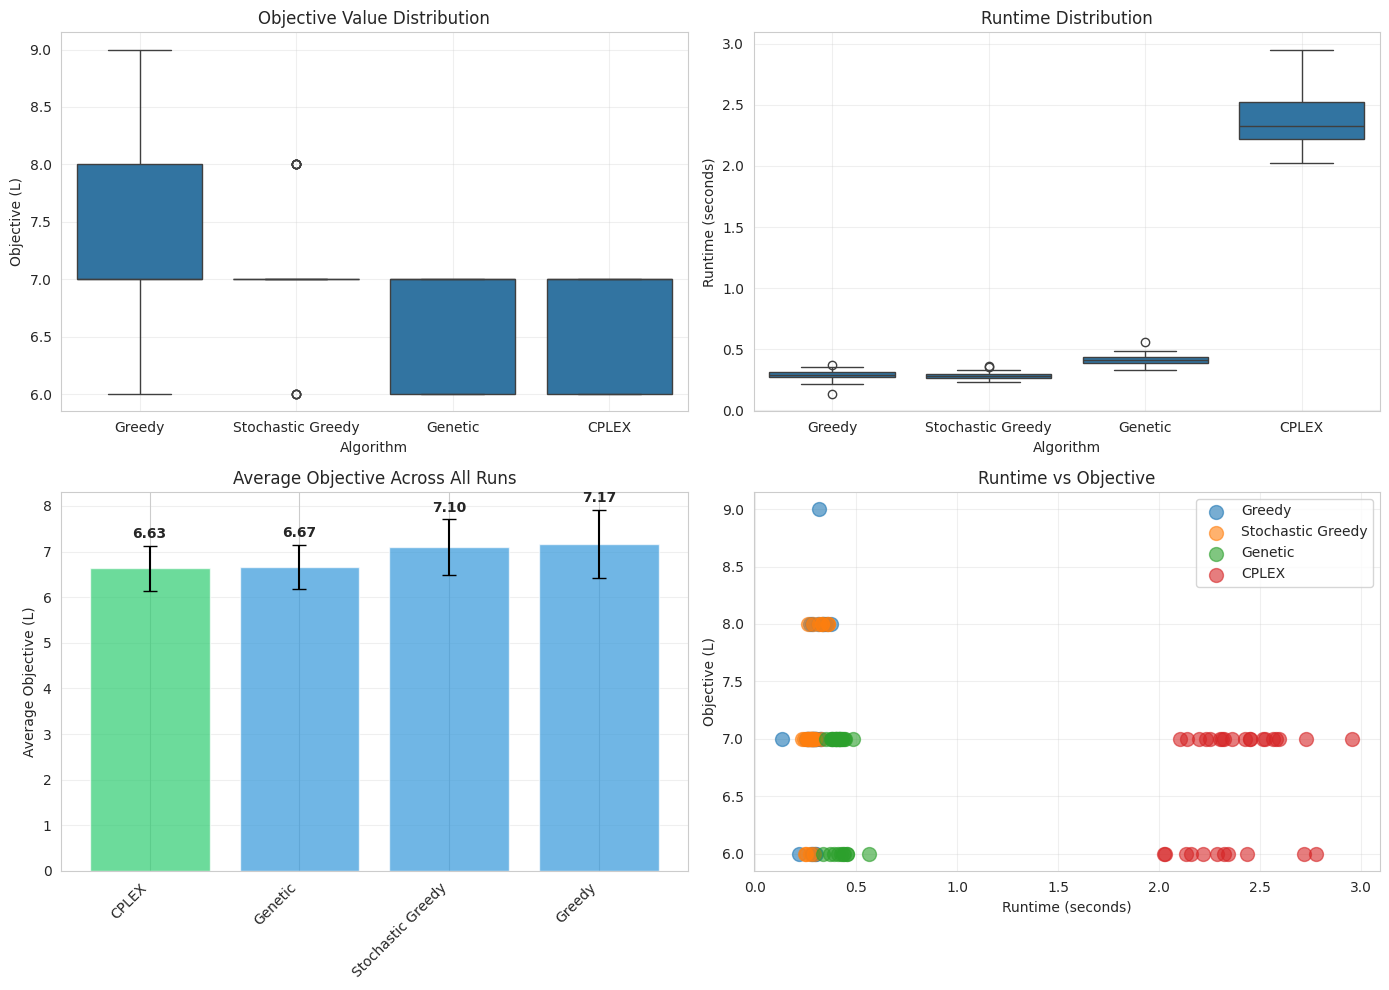

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Objective Value Distribution - Count plot for discrete values
obj_counts = df.groupby(['algorithm', 'objective']).size().reset_index(name='count')
algorithms = df['algorithm'].unique()
obj_values = sorted(df['objective'].unique())
colors_map = {'Greedy': '#e74c3c', 'Stochastic Greedy': '#f39c12', 'Genetic': '#2ecc71', 'CPLEX': '#3498db', 'Branch & Bound': '#9b59b6'}

x_pos = np.arange(len(obj_values))
width = 0.8 / len(algorithms)
for i, algo in enumerate(algorithms):
    algo_data = obj_counts[obj_counts['algorithm'] == algo]
    counts = [algo_data[algo_data['objective'] == obj]['count'].values[0] if obj in algo_data['objective'].values else 0 for obj in obj_values]
    axes[0, 0].bar(x_pos + i * width, counts, width, label=algo, alpha=0.8, color=colors_map.get(algo, f'C{i}'))

axes[0, 0].set_xlabel('Objective Value (L)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency (Count)', fontweight='bold')
axes[0, 0].set_title('Objective Value Distribution (Discrete)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos + width * (len(algorithms) - 1) / 2)
axes[0, 0].set_xticklabels(obj_values)
axes[0, 0].legend(title='Algorithm')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Runtime comparison
sns.boxplot(data=df, x='algorithm', y='runtime', ax=axes[0, 1])
axes[0, 1].set_title('Runtime Distribution')
axes[0, 1].set_xlabel('Algorithm')
axes[0, 1].set_ylabel('Runtime (seconds)')
axes[0, 1].grid(True, alpha=0.3)

# Average Objective Comparison
avg_objectives = df.groupby('algorithm')['objective'].mean().sort_values()
std_objectives = df.groupby('algorithm')['objective'].std()
colors = ['#2ecc71' if avg_objectives[algo] == avg_objectives.min() else '#3498db' for algo in avg_objectives.index]
bars = axes[1, 0].bar(range(len(avg_objectives)), avg_objectives.values, 
                       yerr=std_objectives[avg_objectives.index].values,
                       color=colors, alpha=0.7, capsize=5)
axes[1, 0].set_xticks(range(len(avg_objectives)))
axes[1, 0].set_xticklabels(avg_objectives.index, rotation=45, ha='right')
axes[1, 0].set_title('Average Objective Across All Runs')
axes[1, 0].set_ylabel('Average Objective (L)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, (algo, val) in enumerate(avg_objectives.items()):
    axes[1, 0].text(i, val + std_objectives[algo] + 0.1, f'{val:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

# Runtime vs Objective scatter
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    axes[1, 1].scatter(algo_data['runtime'], algo_data['objective'], 
                      label=algo, s=100, alpha=0.6)
axes[1, 1].set_title('Runtime vs Objective')
axes[1, 1].set_xlabel('Runtime (seconds)')
axes[1, 1].set_ylabel('Objective (L)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Bounding Box Analysis

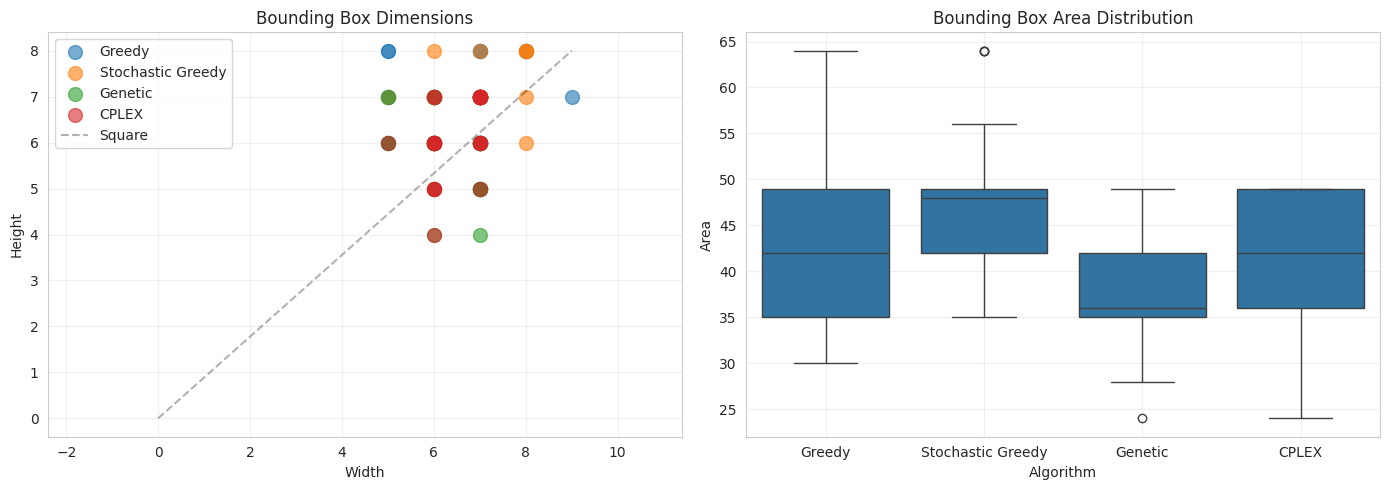

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width vs Height
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    axes[0].scatter(algo_data['bbox_width'], algo_data['bbox_height'], 
                   label=algo, s=100, alpha=0.6)
axes[0].plot([0, df['bbox_width'].max()], [0, df['bbox_height'].max()], 
            'k--', alpha=0.3, label='Square')
axes[0].set_title('Bounding Box Dimensions')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Area distribution
df['bbox_area'] = df['bbox_width'] * df['bbox_height']
sns.boxplot(data=df, x='algorithm', y='bbox_area', ax=axes[1])
axes[1].set_title('Bounding Box Area Distribution')
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Area')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Statistical Tests

In [223]:
from scipy import stats

print("\n" + "="*80)
print("STATISTICAL TESTS (Pairwise Comparisons)")
print("="*80)

algorithms = df['algorithm'].unique()
for i, algo1 in enumerate(algorithms):
    for algo2 in algorithms[i+1:]:
        data1 = df[df['algorithm'] == algo1]['objective']
        data2 = df[df['algorithm'] == algo2]['objective']
        
        # Wilcoxon rank-sum test (Mann-Whitney U)
        statistic, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        print(f"\n{algo1} vs {algo2}:")
        print(f"  Mean difference: {data1.mean() - data2.mean():.3f}")
        print(f"  Mann-Whitney U test: statistic={statistic:.2f}, p-value={p_value:.4f}")
        
        if p_value < 0.05:
            if data1.mean() < data2.mean():
                print(f"  ✓ {algo1} is significantly better (p < 0.05)")
            else:
                print(f"  ✓ {algo2} is significantly better (p < 0.05)")
        else:
            print(f"  No significant difference (p >= 0.05)")


STATISTICAL TESTS (Pairwise Comparisons)

Greedy vs Stochastic Greedy:
  Mean difference: 0.067
  Mann-Whitney U test: statistic=468.00, p-value=0.7699
  No significant difference (p >= 0.05)

Greedy vs Genetic:
  Mean difference: 0.500
  Mann-Whitney U test: statistic=615.00, p-value=0.0055
  ✓ Genetic is significantly better (p < 0.05)

Greedy vs CPLEX:
  Mean difference: 0.533
  Mann-Whitney U test: statistic=625.50, p-value=0.0034
  ✓ CPLEX is significantly better (p < 0.05)

Stochastic Greedy vs Genetic:
  Mean difference: 0.433
  Mann-Whitney U test: statistic=610.00, p-value=0.0052
  ✓ Genetic is significantly better (p < 0.05)

Stochastic Greedy vs CPLEX:
  Mean difference: 0.467
  Mann-Whitney U test: statistic=621.50, p-value=0.0031
  ✓ CPLEX is significantly better (p < 0.05)

Genetic vs CPLEX:
  Mean difference: 0.033
  Mann-Whitney U test: statistic=465.00, p-value=0.7953
  No significant difference (p >= 0.05)


## 9. Export Results

In [224]:
# Save results to CSV
output_file = 'algorithm_comparison_results.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

# Save summary to text file
summary_file = 'algorithm_comparison_summary.txt'
with open(summary_file, 'w') as f:
    f.write("MDSSP Algorithm Comparison Summary\n")
    f.write("="*80 + "\n\n")
    f.write(f"Configuration:\n")
    f.write(f"  Tiles: {TILES}\n")
    f.write(f"  Tile size: {N} × {M}\n")
    f.write(f"  Number of runs: {NUM_RUNS}\n\n")
    f.write(str(summary))
    f.write("\n\n")
    
print(f"Summary saved to {summary_file}")

print("\n✓ Analysis complete!")

Results saved to algorithm_comparison_results.csv
Summary saved to algorithm_comparison_summary.txt

✓ Analysis complete!


## Summary

The notebook has completed running {NUM_RUNS} experiments for each algorithm and identified the best solutions. Key findings are displayed in the visualizations above.